total de linhas de apenas 2019(1 e 2 semestre):  (968047, 68)
total de linhas de apenas 2020 e 2021 (1 e 2 semestre):  (1229187, 68)
------------------------------------------------------------
qtde de inscritos apenas de 2019 (1 e 2 semestre)


,situacao_fies,qtde_inscritos
0,CONTRATADA,72213
1,INSCRIÇÃO POSTERGADA,37
2,LISTA DE ESPERA,334392
3,NÃO CONTRATADO,467184
4,OPÇÃO NÃO CONTRATADA,62313
5,PARTICIPACAO CANCELADA PELO CANDIDATO,30320
6,PRÉ-SELECIONADO,163
7,REJEITADA PELA CPSA,1425


------------------------------------------------------------
qtde de inscritos apenas de 2020 e 2021 (1 e 2 semestre)


,situacao_fies,qtde_inscritos
0,CONTRATADA,88156
1,INSCRIÇÃO POSTERGADA,2287
2,LISTA DE ESPERA,406306
3,NÃO CONTRATADO,557420
4,OPÇÃO NÃO CONTRATADA,77156
5,PARTICIPACAO CANCELADA PELO CANDIDATO,80882
6,PRÉ-SELECIONADO,12760
7,REJEITADA PELA CPSA,4220


--- Quantidade de NaNs por coluna ---
renda_per_capita                                                                   0
gap                                                                                1
nome_cine_area_geral_Artes e humanidades                                           0
nome_cine_area_geral_Ciências naturais, matemática e estatística                   0
nome_cine_area_geral_Ciências sociais, comunicação e informação                    0
nome_cine_area_geral_Computação e Tecnologias da Informação e Comunicação (TIC)    0
nome_cine_area_geral_Educação                                                      0
nome_cine_area_geral_Engenharia, produção e construção                             0
nome_cine_area_geral_Negócios, administração e direito                             0
nome_cine_area_geral_Saúde e bem-estar                                             0
nome_cine_area_geral_Serviços                                                      0
dtype: int64
coluna x linha

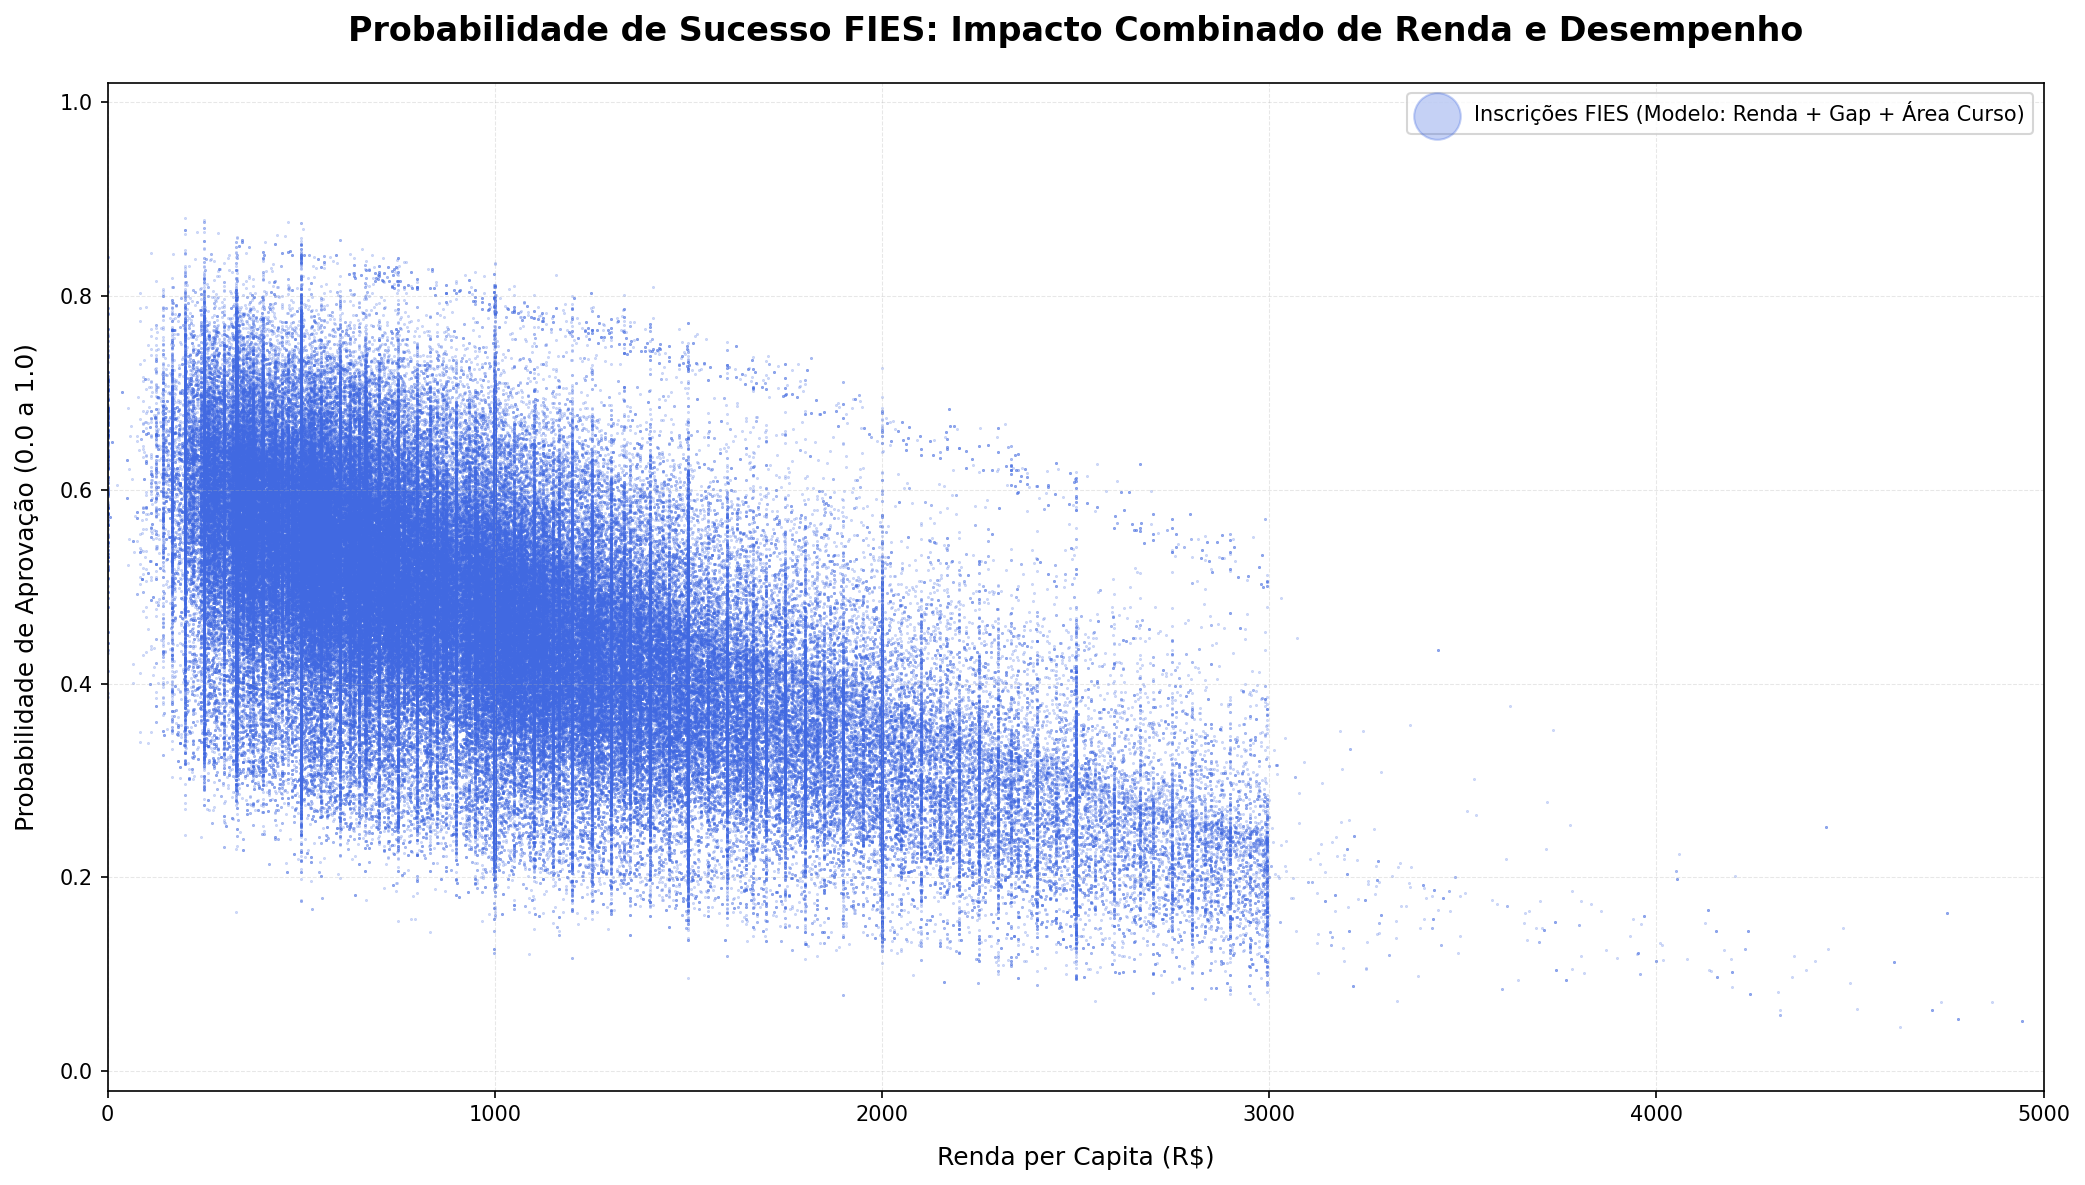

Gráfico Finalizado: 539,396 registros processados com sucesso.


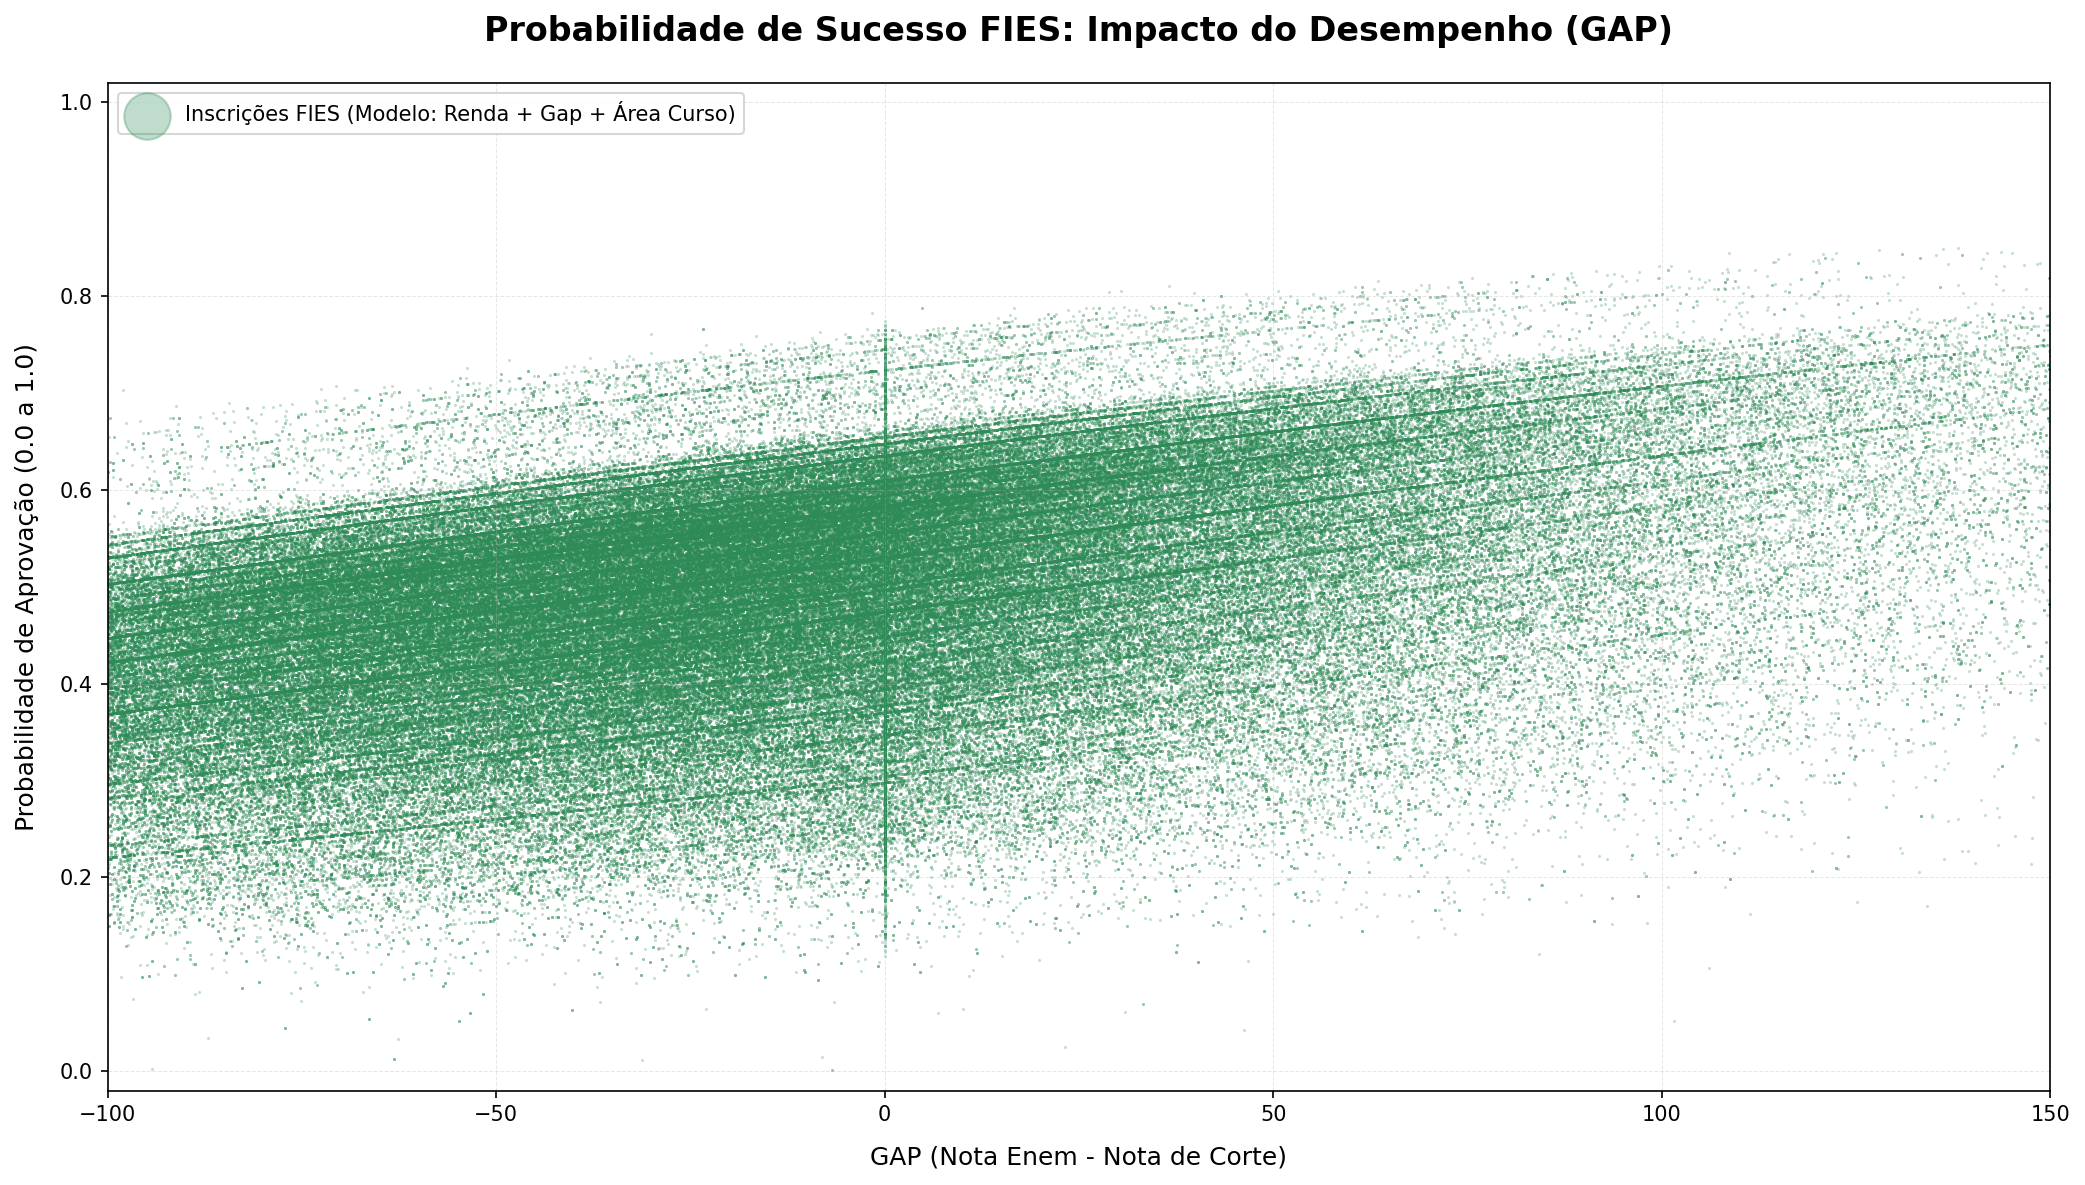

Gráfico Finalizado: 539,396 registros processados com sucesso.
--- Distribuição de Inscritos por Faixa de Renda ---


,faixa_renda,qtd_inscritos,percentual
0,0-500,141655,26.28%
1,501-1000,211630,39.26%
2,1001-1500,118673,22.02%
3,1501-2000,40833,7.58%
4,2001-2500,17397,3.23%
5,2501-3000,8516,1.58%
6,+ de 3001,326,0.06%


--- QUEM MANDA NO FIES? (PESO CORRIGIDO POR ESCALA) ---


,Variável,Impacto Real (Peso Corrigido)
0,renda_per_capita,-0.354928
1,"nome_cine_area_geral_Negócios, administração e...",-0.332105
2,nome_cine_area_geral_Educação,-0.307794
3,gap,0.265565
4,nome_cine_area_geral_Saúde e bem-estar,-0.249334
5,nome_cine_area_geral_Computação e Tecnologias ...,-0.246403
6,"nome_cine_area_geral_Engenharia, produção e co...",-0.205946
7,"nome_cine_area_geral_Ciências sociais, comunic...",-0.168471
8,nome_cine_area_geral_Serviços,-0.157428
9,nome_cine_area_geral_Artes e humanidades,-0.121798


,ano,semestre,nome_cine_area_geral,qtde_de_inscritos
0,2019,1,"Agricultura, silvicultura, pesca e veterinária",23682
1,2019,1,Artes e humanidades,6961
2,2019,1,"Ciências naturais, matemática e estatística",2994
3,2019,1,"Ciências sociais, comunicação e informação",48333
4,2019,1,Computação e Tecnologias da Informação e Comun...,19631
5,2019,1,Educação,29571
6,2019,1,"Engenharia, produção e construção",73353
7,2019,1,"Negócios, administração e direito",189823
8,2019,1,Saúde e bem-estar,290709
9,2019,1,Serviços,11674


------------------------------------------------------------
AVALIAÇÃO DE PERFORMANCE (MÉTRICAS KDD):
Previsões geradas com sucesso!

-> Acurácia Geral do Modelo: 58.97%

------------------------------------------------------------


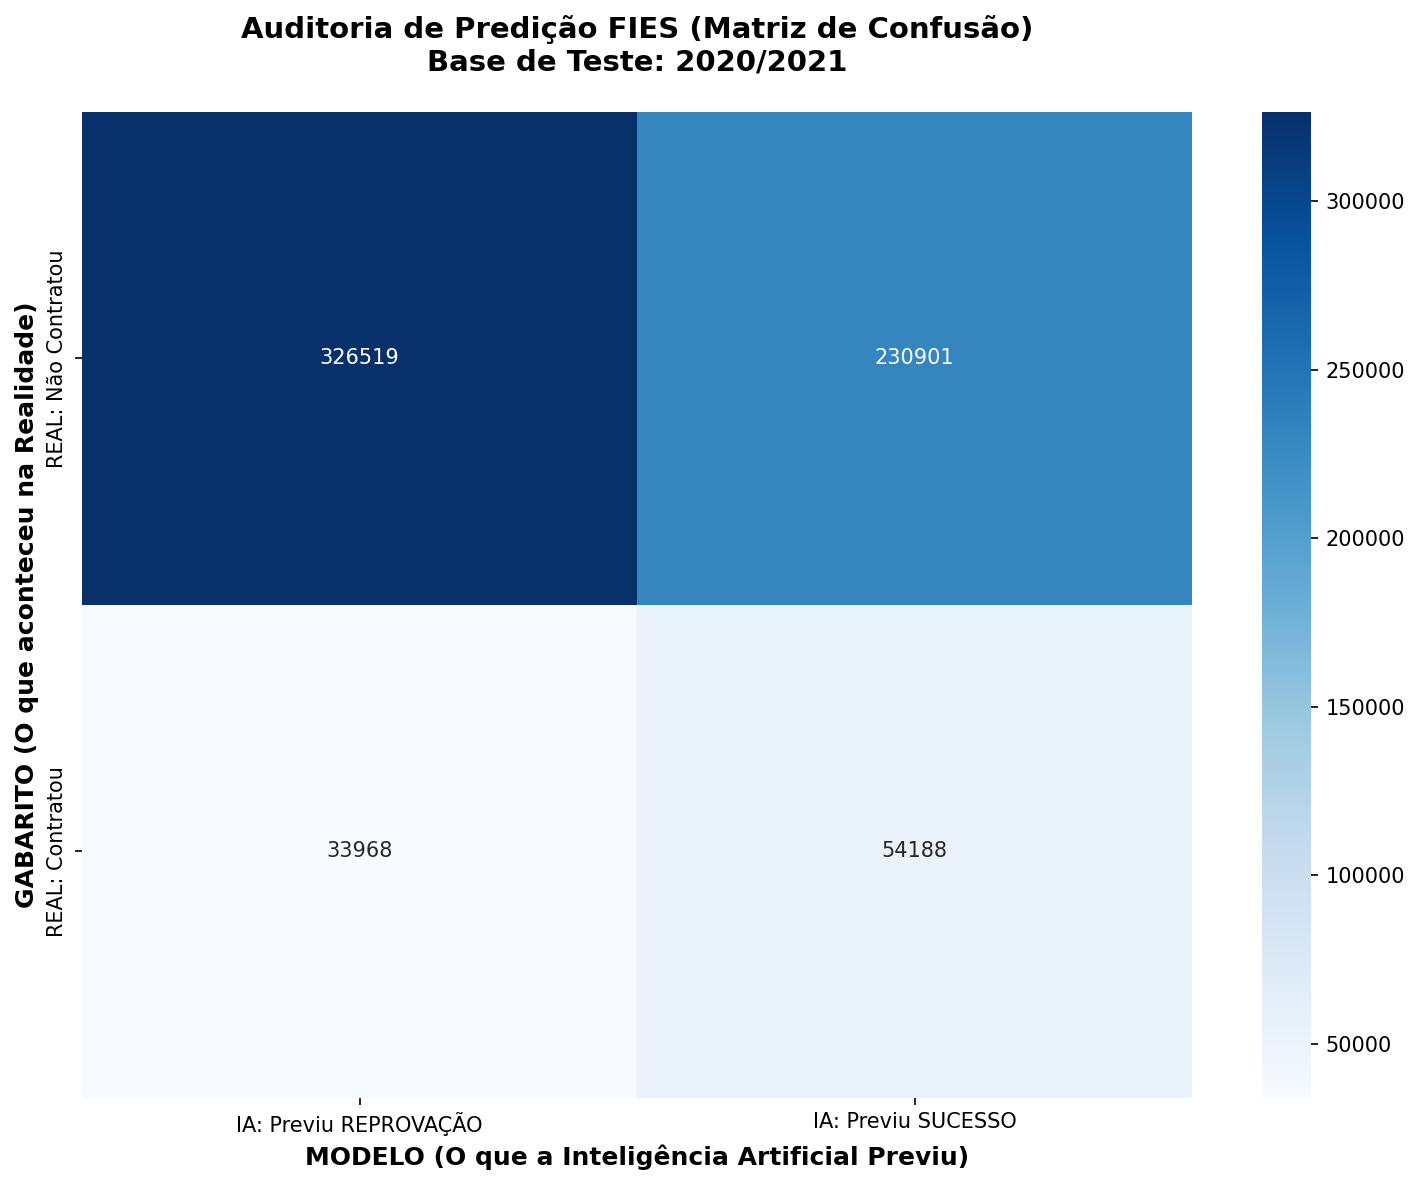


    CONCLUSÕES DO MODELO DE PREDIÇÃO FIES (VALIDAÇÃO 2019-2021)

    1. DINÂMICA DOS CURSOS E FUNIL DE CONVERSÃO:
    A área de "Saúde e bem-estar" concentra o maior volume isolado de inscritos 
    (1.049.914), mas o modelo revela que "Negócios, Administração e Direito" (-0.33) 
    e "Educação" (-0.30) possuem as maiores penalidades para contratação. Isso 
    indica um funil de vagas mais estreito e maior barreira para a conversão final.

    2. PREVALÊNCIA SOCIOECONÔMICA (RENDA COMO FILTRO):
    A RENDA PER CAPITA é a variável de maior poder preditivo (-0.35), superando o 
    GAP acadêmico (0.26). A correlação de Pearson de -0,71 entre renda e percentual 
    de financiamento confirma que o governo reduz o aporte conforme a renda sobe, 
    empurrando o custo para o aluno e inviabilizando o contrato para muitos.

    3. O GARGALO DO "NÃO CONTRATADO" E O RISCO DE CRÉDITO:
    O verdadeiro bloqueio ocorre no status 'NÃO CONTRATADO'. Conclui-se que o rigor 
    bancário e o medo da 

In [ ]:
import sys
import pandas as pd
from src.staging import staging_fies, staging_inep
from src.transform_layer_1 import transform_inscritos, transform_ofertas, transform_inep, verificar_colunas_inep
from src.transform_layer_2 import tratar_nans_cine_inscritos, tratar_nans_cine_ofertas
from src.trasnform_layer_3 import processar_modalidades_e_peneira
from src.load import load_inscritos,load_ofertas,auditoria_inscritos_carregados,auditoria_ofertas_carregadas,exportar_para_sqlite
from src.analise_001 import gerar_dataset_candidatos_unicos_por_Prioridade_inicial
from src.analise_002 import eda_gerar_dataset_com_varias_analises
from src.analise_003 import eda_gerar_funil_de_selecao_6_etapas
from src.analise_004 import analise_fuga_cerebros_de_regioes
from src.analise_005 import verificar_qtde_inscritos_por_ano_e_semestre_nacional_e_regional
from src.analise_006 import gerar_dataset_e_grafico_heatmap_quem_sao_os_inscritos_contratados
from src.analise_007 import orquestrador_inicial_inscritos, orquestrador_ja_rodado_inscritos
#from src.analise_008 import orquestrador_inicial_candidatos




comando = 'analise'
etapa = '7'

# --- CAMADA: STAGING ---
if comando == "staging":
    staging_fies()
    staging_inep()

# --- CAMADA: TRANSFORM ---
elif comando == "transform":

    if etapa == "1":
        transform_inep()
    elif etapa == "2":
        transform_inscritos()
    elif etapa == "3":
        transform_ofertas()
    elif etapa == "4":
        verificar_colunas_inep()
    elif etapa == "5":
        tratar_nans_cine_inscritos()
    elif etapa == "6":
        tratar_nans_cine_ofertas()
    elif etapa == "7":
        processar_modalidades_e_peneira()
    elif etapa == "all":
        transform_inep()
        transform_inscritos()
        transform_ofertas()
        verificar_colunas_inep()
        tratar_nans_cine_inscritos()
        tratar_nans_cine_ofertas()
        processar_modalidades_e_peneira()

elif comando == "load":

    load_inscritos()
    load_ofertas()
    auditoria_inscritos_carregados()
    auditoria_ofertas_carregadas()
    exportar_para_sqlite()

elif comando == 'analise':

    if etapa == "1":
        gerar_dataset_candidatos_unicos_por_Prioridade_inicial()

    elif etapa == "2":
        eda_gerar_dataset_com_varias_analises()

    elif etapa == "3":
        eda_gerar_funil_de_selecao_6_etapas()

    elif etapa == "4":
        analise_fuga_cerebros_de_regioes()

    elif etapa == "5":
        verificar_qtde_inscritos_por_ano_e_semestre_nacional_e_regional()

    elif etapa == "6":
        gerar_dataset_e_grafico_heatmap_quem_sao_os_inscritos_contratados()

    elif etapa == "7":
        orquestrador_inicial_inscritos()
    
    elif etapa == "7.1":
        orquestrador_ja_rodado_inscritos()

    #elif etapa == "8":
    #    orquestrador_inicial_candidatos()